# Project 6: Turbofan Engine RUL Prediction
# Predictive Maintenance using NASA CMAPSS FD001 Dataset

## 1. Load Training Data

In [76]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

cols = ['unit_nr', 'time_cycles', 'op_setting_1', 'op_setting_2', 'op_setting_3'] + [f'sensor_{i}' for i in range(1,22)]
train = pd.read_csv('train_FD001.txt', sep=r'\s+', header=None, names=cols)

In [61]:
print('Shape:', train.shape)
print('Number of engines:', train['unit_nr'].nunique())
train.head()

Shape: (20631, 26)
Number of engines: 100


,unit_nr,time_cycles,op_setting_1,op_setting_2,op_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


## 2. Compute Remaining Useful Life (RUL)

In [62]:
# For each engine, find its maximum cycle, then RUL = max_cycle - current_cycle
max_cycles = train.groupby('unit_nr')['time_cycles'].max().reset_index()
max_cycles.columns = ['unit_nr', 'max_cycles']
train = train.merge(max_cycles, on='unit_nr')
train['RUL'] = train['max_cycles'] - train['time_cycles']
train.drop('max_cycles', axis=1, inplace=True)

# Verify: for any engine, RUL should start high and reach 0 at the last cycle
train[train['unit_nr'] == 1][['unit_nr', 'time_cycles', 'RUL']].head(10)

,unit_nr,time_cycles,RUL
0,1,1,191
1,1,2,190
2,1,3,189
3,1,4,188
4,1,5,187
5,1,6,186
6,1,7,185
7,1,8,184
8,1,9,183
9,1,10,182


## 3. Visualize Sensor Degradation (Engine 1)

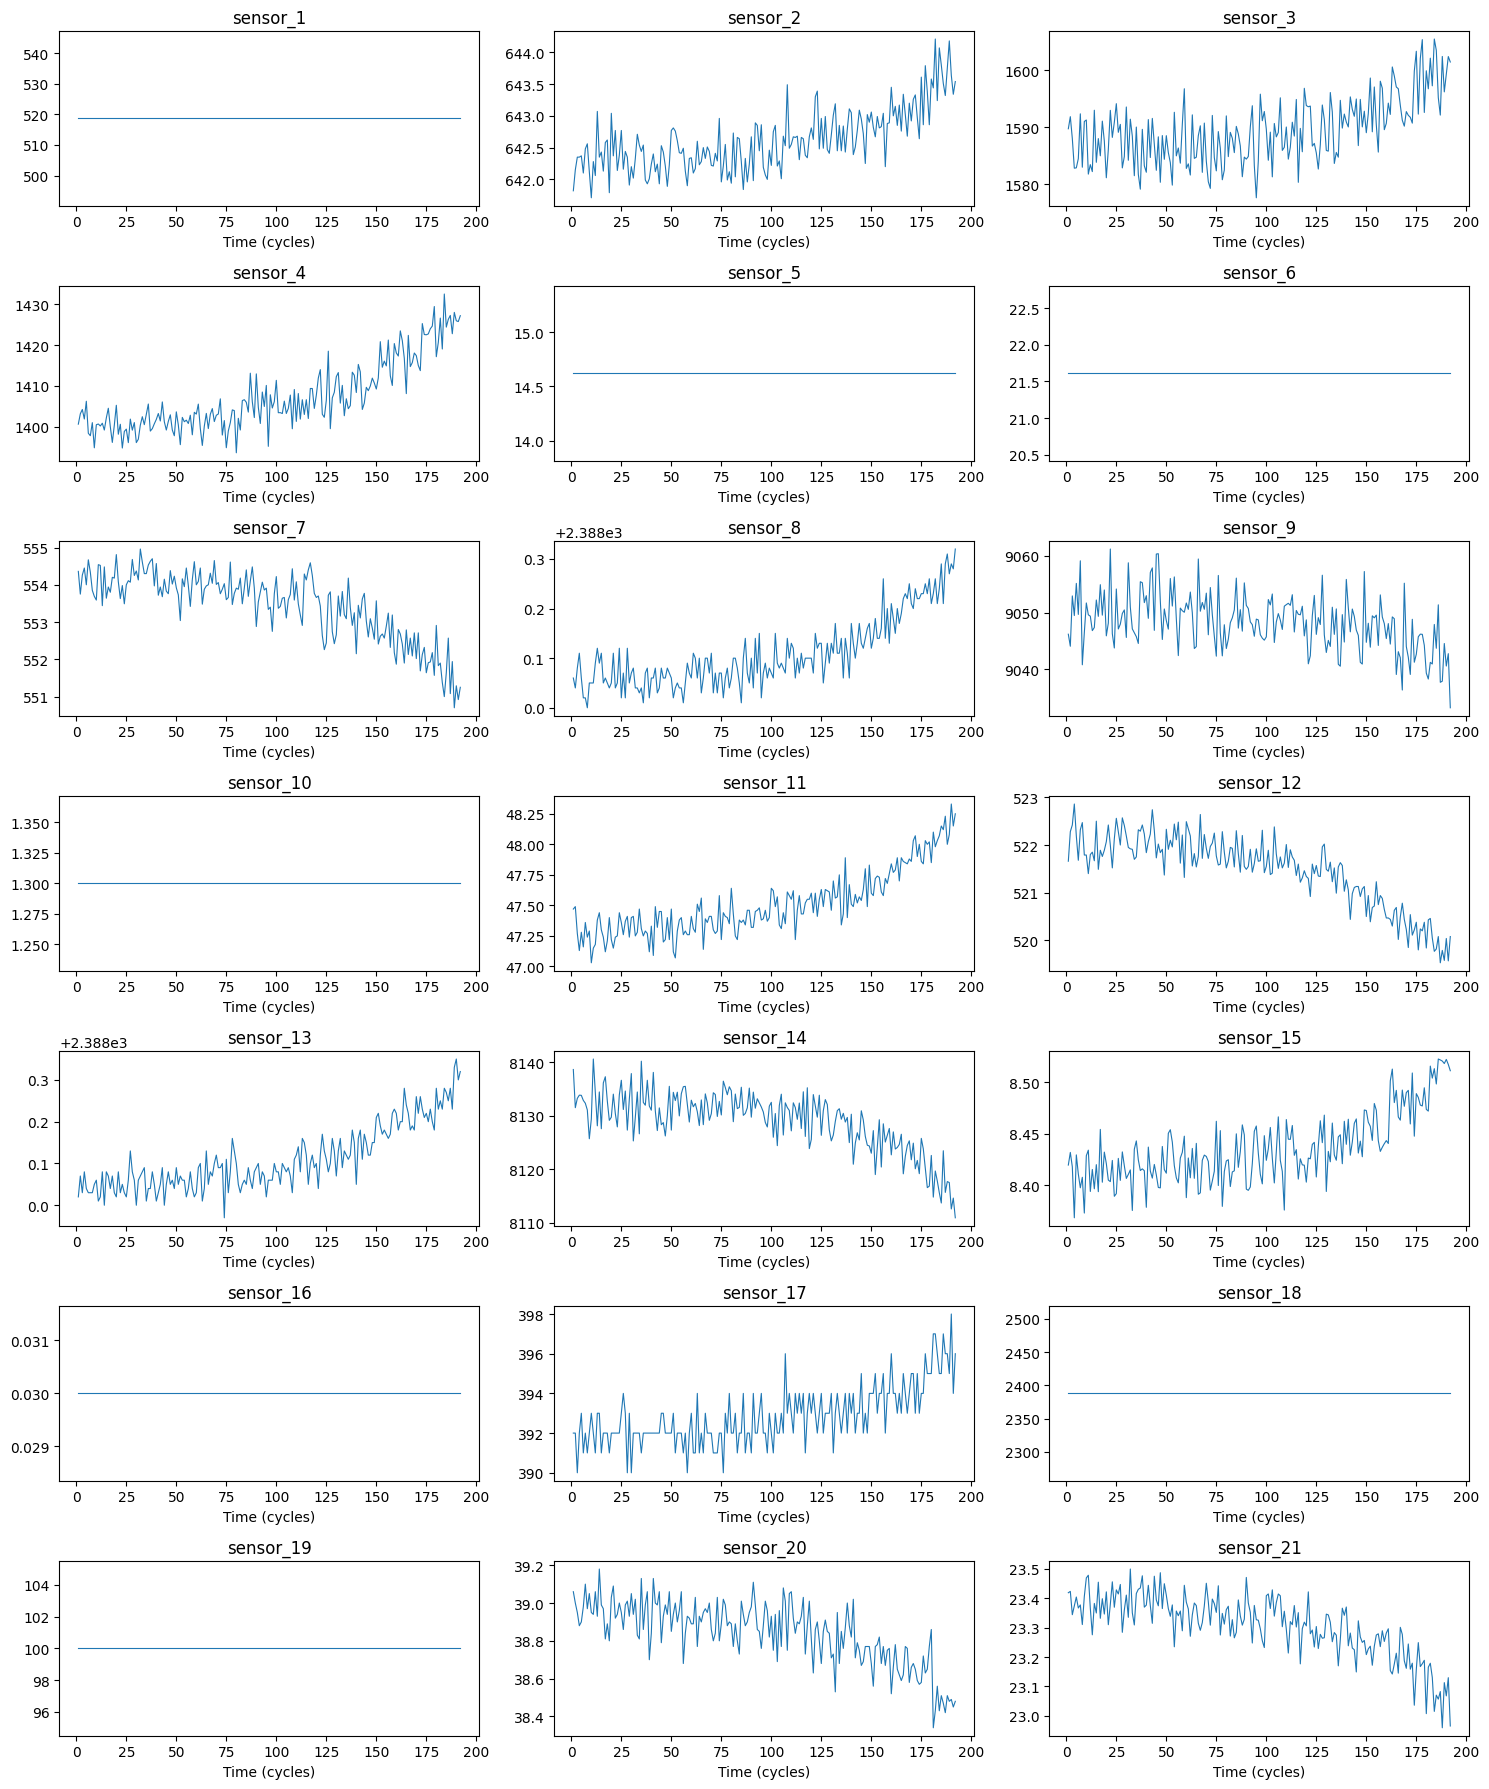

In [63]:
import matplotlib.pyplot as plt

engine1 = train[train['unit_nr'] == 1]
sensors = [f'sensor_{i}' for i in range(1, 22)]

fig, axes = plt.subplots(7, 3, figsize=(15, 18))
axes = axes.flatten()
for i, sensor in enumerate(sensors):
    axes[i].plot(engine1['time_cycles'], engine1[sensor], linewidth=0.8)
    axes[i].set_title(sensor)
    axes[i].set_xlabel('Time (cycles)')
plt.tight_layout()
plt.show()

## 4. Verify Degradation Patterns Across Engines
To confirm that sensor degradation trends are consistent and not specific to a single engine, the same 21 sensors are plotted for engine #50. Similar trends would indicate that the patterns are generalizable across the fleet.

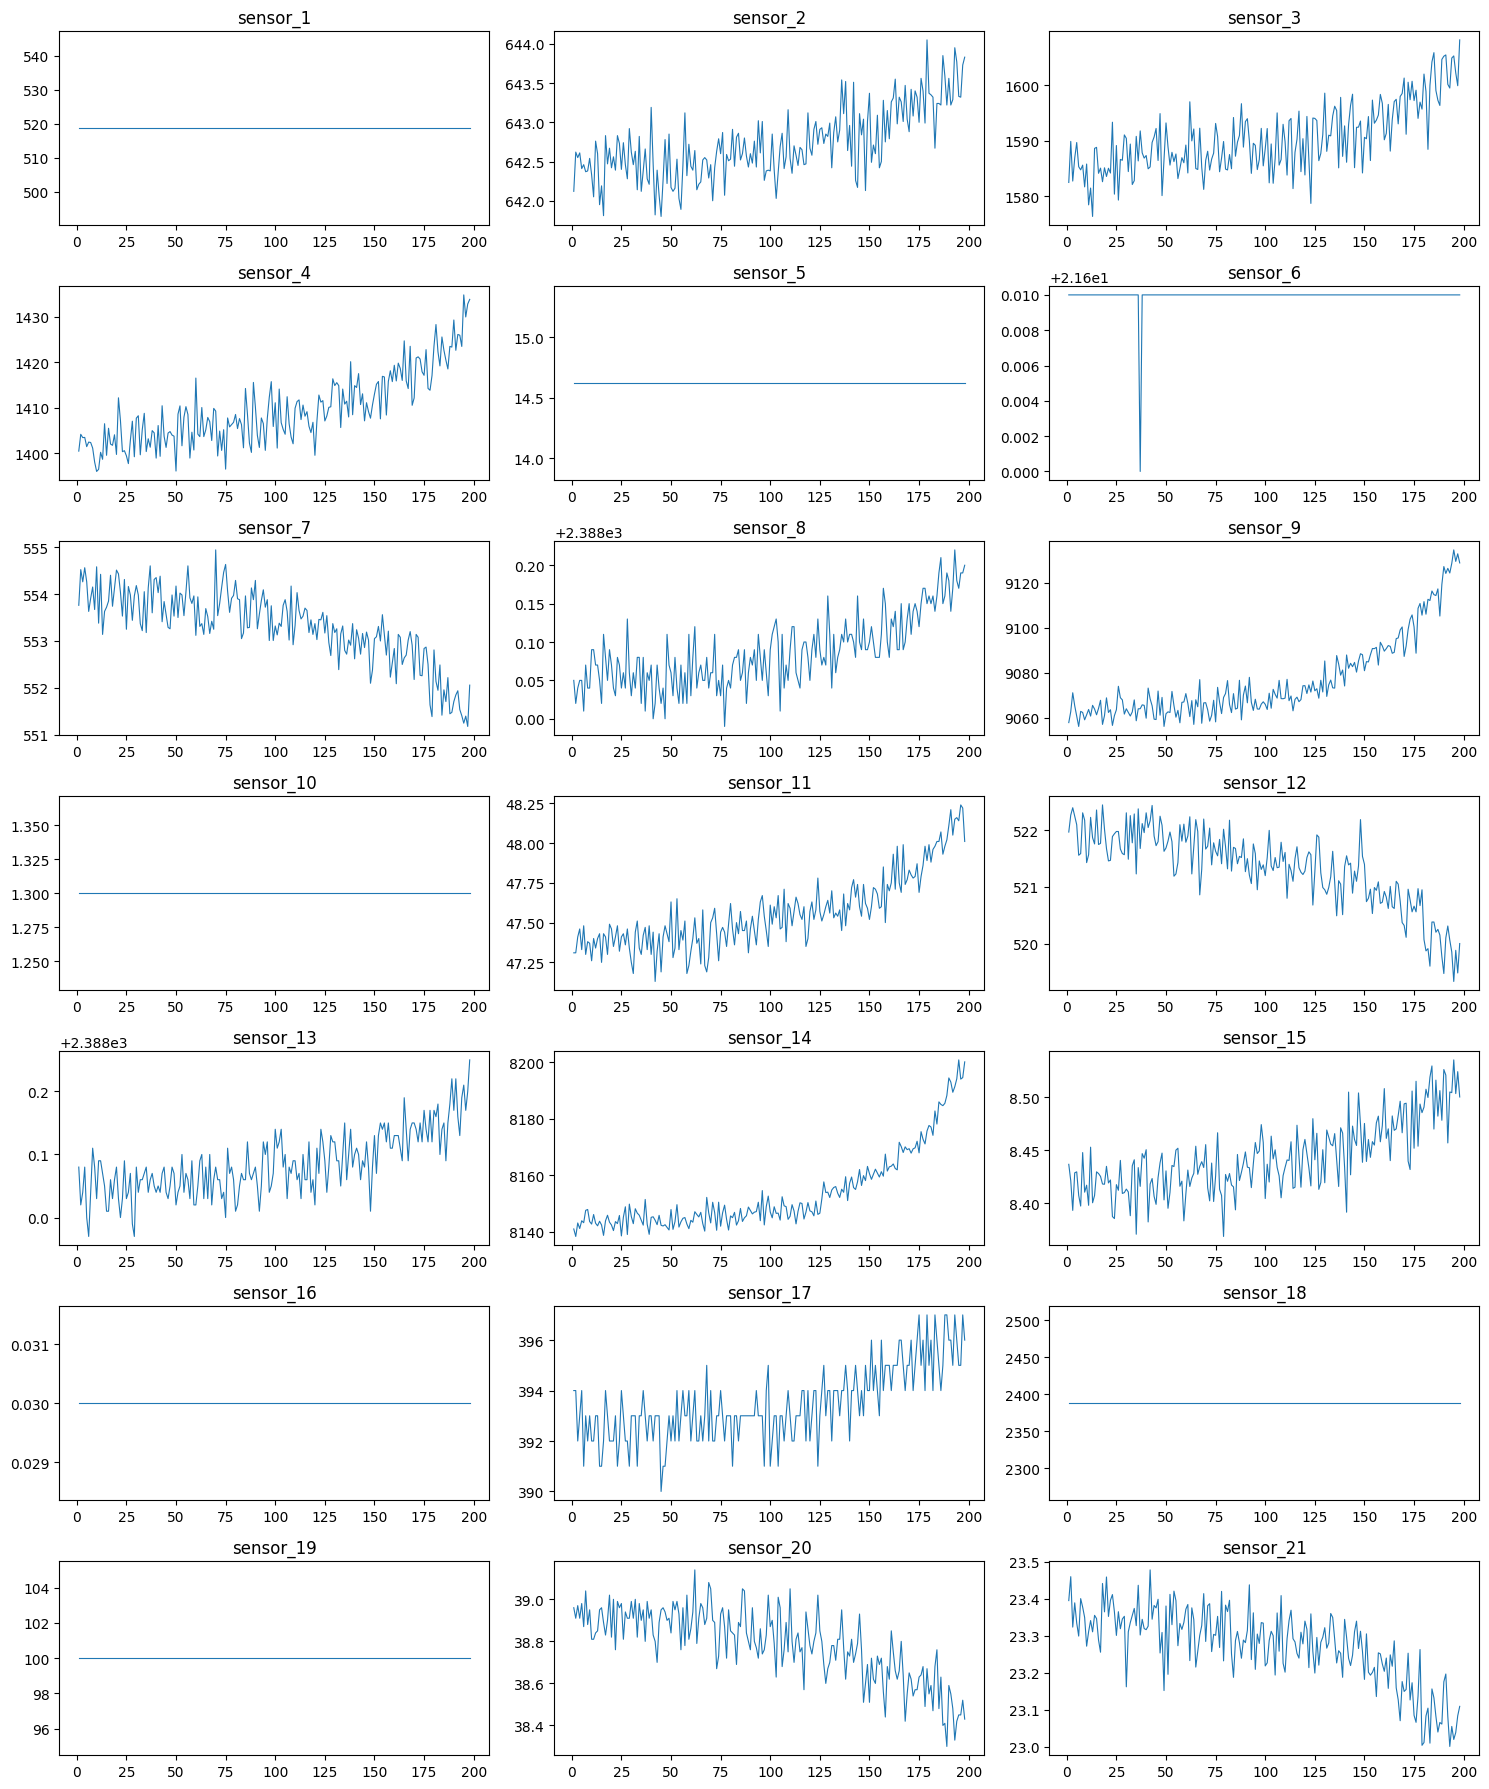

In [64]:
engine50 = train[train['unit_nr'] == 50]
fig, axes = plt.subplots(7, 3, figsize=(15, 18))
axes = axes.flatten()
for i, sensor in enumerate(sensors):
    axes[i].plot(engine50['time_cycles'], engine50[sensor], linewidth=0.8)
    axes[i].set_title(sensor)
plt.tight_layout()
plt.show()

## 5. Feature Engineering for RUL Prediction
Raw sensor values alone may not capture degradation well. Rolling statistics (mean, standard deviation, trend) over recent cycles can help the model detect wear patterns. These engineered features are created for each engine independently to avoid data leakage across units.

In [65]:
# Sort data by engine and cycle (already sorted, but being safe)
train = train.sort_values(['unit_nr', 'time_cycles'])

# Create rolling features for each sensor (window = 10 cycles)
window = 10
sensors = [f'sensor_{i}' for i in range(1, 22)]

for sensor in sensors:
    # Rolling mean
    train[f'{sensor}_roll_mean'] = train.groupby('unit_nr')[sensor].transform(
        lambda x: x.rolling(window, min_periods=1).mean()
    )
    # Rolling standard deviation
    train[f'{sensor}_roll_std'] = train.groupby('unit_nr')[sensor].transform(
        lambda x: x.rolling(window, min_periods=1).std()
    )

print('New shape:', train.shape)
train.head()

New shape: (20631, 69)


,unit_nr,time_cycles,op_setting_1,op_setting_2,op_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_17_roll_mean,sensor_17_roll_std,sensor_18_roll_mean,sensor_18_roll_std,sensor_19_roll_mean,sensor_19_roll_std,sensor_20_roll_mean,sensor_20_roll_std,sensor_21_roll_mean,sensor_21_roll_std
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,392.000000,NaN,2388.0,NaN,100.0,NaN,39.060000,NaN,23.419000,NaN
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,392.000000,0.000000,2388.0,0.0,100.0,0.0,39.030000,0.042426,23.421300,0.003253
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,391.333333,1.154701,2388.0,0.0,100.0,0.0,39.003333,0.055076,23.395600,0.044573
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,391.500000,1.000000,2388.0,0.0,100.0,0.0,38.972500,0.076322,23.390175,0.037977
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,391.800000,1.095445,2388.0,0.0,100.0,0.0,38.958000,0.073621,23.393020,0.033498


In [66]:
# Add linear trend over the last 10 cycles for key sensors
def slope(x):
    if len(x) < 2:
        return 0
    return np.polyfit(np.arange(len(x)), x, 1)[0]

for sensor in sensors:
    train[f'{sensor}_trend'] = train.groupby('unit_nr')[sensor].transform(
        lambda x: x.rolling(window, min_periods=1).apply(slope, raw=True)
    )

print('Final shape after trend features:', train.shape)

Final shape after trend features: (20631, 90)


In [67]:
print('NaN count:', train.isnull().sum().sum())
if train.isnull().sum().sum() > 0:
    train = train.fillna(0)
    print('Filled NaNs with 0.')

NaN count: 2100
Filled NaNs with 0.


## 6. Prepare Features and Target
Drop raw sensor columns and keep engineered features for modeling. Also drop identifier columns.

In [68]:
# Drop raw sensor columns and non-feature columns
drop_cols = ['unit_nr', 'time_cycles'] + [f'sensor_{i}' for i in range(1, 22)]
X = train.drop(columns=drop_cols + ['RUL'])
y = train['RUL']

print('Feature matrix shape:', X.shape)
print('Target shape:', y.shape)

Feature matrix shape: (20631, 66)
Target shape: (20631,)


## 7. Train/Test Split (by Engine)
Splitting by engine prevents data leakage — the model must predict on engines it hasn't seen during training.

In [69]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Get unique engine IDs
engines = train['unit_nr'].unique()
train_engines, test_engines = train_test_split(engines, test_size=0.2, random_state=42)

# Split the data
train_data = train[train['unit_nr'].isin(train_engines)]
test_data = train[train['unit_nr'].isin(test_engines)]

# Define drop columns (add op_setting columns too)
drop_cols = ['unit_nr', 'time_cycles', 'op_setting_1', 'op_setting_2', 'op_setting_3'] + [f'sensor_{i}' for i in range(1, 22)]

X_train = train_data.drop(columns=drop_cols + ['RUL']).fillna(0)
y_train = train_data['RUL']
X_test = test_data.drop(columns=drop_cols + ['RUL']).fillna(0)
y_test = test_data['RUL']

print('Train engines:', len(train_engines), '| Test engines:', len(test_engines))
print('X_train:', X_train.shape, '| X_test:', X_test.shape)

Train engines: 80 | Test engines: 20
X_train: (16561, 63) | X_test: (4070, 63)


In [70]:
# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## 8. Baseline Model — Linear Regression

In [71]:
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)

rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
mae_lr = mean_absolute_error(y_test, y_pred_lr)
r2_lr = r2_score(y_test, y_pred_lr)

print(f'Linear Regression — RMSE: {rmse_lr:.2f} cycles | MAE: {mae_lr:.2f} cycles | R²: {r2_lr:.3f}')

Linear Regression — RMSE: 35.80 cycles | MAE: 28.13 cycles | R²: 0.703


## 9. Random Forest Regressor

In [72]:
rf = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
rf.fit(X_train_scaled, y_train)
y_pred_rf = rf.predict(X_test_scaled)

rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
mae_rf = mean_absolute_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print(f'Random Forest — RMSE: {rmse_rf:.2f} cycles | MAE: {mae_rf:.2f} cycles | R²: {r2_rf:.3f}')

Random Forest — RMSE: 34.08 cycles | MAE: 24.39 cycles | R²: 0.731


## 10. Model Comparison

               Model       RMSE        MAE        R²
0  Linear Regression  35.804842  28.134358  0.702567
1      Random Forest  34.078584  24.393600  0.730556


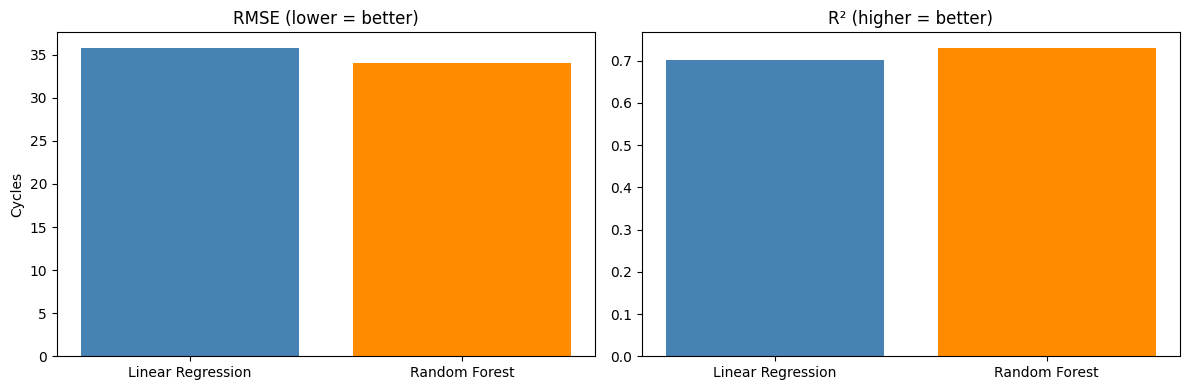

In [73]:
comparison = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest'],
    'RMSE': [rmse_lr, rmse_rf],
    'MAE': [mae_lr, mae_rf],
    'R²': [r2_lr, r2_rf]
})
print(comparison)

# Visual comparison
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.bar(comparison['Model'], comparison['RMSE'], color=['steelblue', 'darkorange'])
ax1.set_title('RMSE (lower = better)')
ax1.set_ylabel('Cycles')

ax2.bar(comparison['Model'], comparison['R²'], color=['steelblue', 'darkorange'])
ax2.set_title('R² (higher = better)')

plt.tight_layout()
plt.show()

## 11. Feature Importance

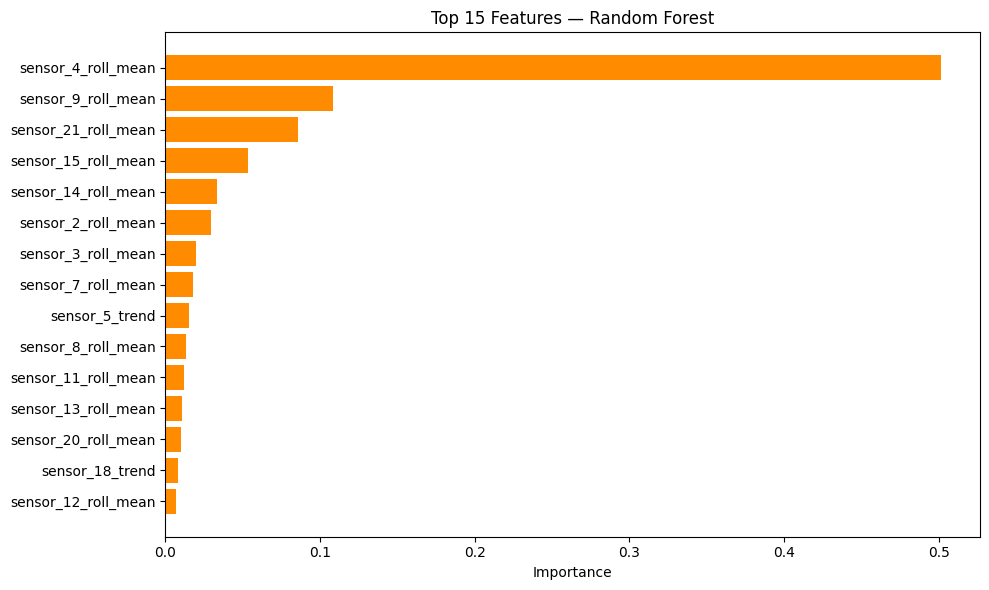

In [74]:
importances = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=False).head(15)

plt.figure(figsize=(10, 6))
plt.barh(importances['Feature'][::-1], importances['Importance'][::-1], color='darkorange')
plt.title('Top 15 Features — Random Forest')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

## 12. Predicted vs Actual RUL

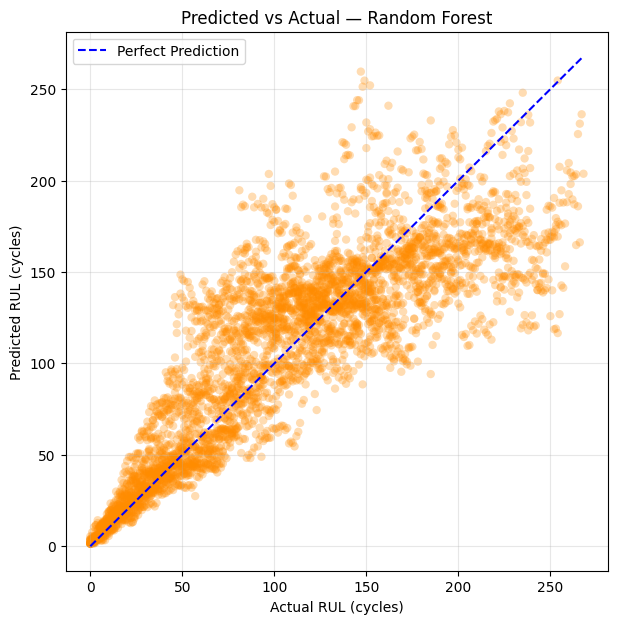

In [75]:
plt.figure(figsize=(7, 7))
plt.scatter(y_test, y_pred_rf, alpha=0.3, color='darkorange', edgecolors='none')
plt.plot([0, y_test.max()], [0, y_test.max()], 'b--', label='Perfect Prediction')
plt.xlabel('Actual RUL (cycles)')
plt.ylabel('Predicted RUL (cycles)')
plt.title('Predicted vs Actual — Random Forest')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 13. Summary
- Random Forest outperformed Linear Regression on all metrics.
- RMSE of 34.08 cycles means predictions are off by roughly 0.731 cycles on average.
- Feature importance confirms that rolling trend and mean features of degrading sensors are the strongest predictors.
- Next step: Evaluate on the FD001 test set using the provided RUL file.